In [35]:
# Import Packages
from __future__ import annotations
import pandas as pd
import numpy as np 
from pyproj import CRS, Transformer

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pymap3d as pm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display, HTML

import os
import sys
import imageio.v2 as imageio
import glob
import open3d as o3d
import healpix as hp

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from geopy.distance import great_circle
from scipy.interpolate import CubicSpline

from matplotlib.patches import Polygon
from astropy_healpix import HEALPix
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from matplotlib.cm import ScalarMappable

import gzip
import shutil
import os
from pathlib import Path

from urllib.request import urlopen, urlretrieve
from urllib.error import HTTPError, URLError
import tempfile
import plotly.graph_objects as go
from shapely.geometry import Point
from shapely.strtree import STRtree
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

import cartopy.feature as cfeature
from shapely.geometry import LineString, MultiLineString

from bokeh.plotting import figure, show, output_notebook
from bokeh.plotting import figure, show
from bokeh.layouts import column, row
from bokeh.models import (
    ColumnDataSource,
    Slider,
    Select,
    CustomJS,
    Div,
    CheckboxGroup,
    HoverTool,
    Legend,
    LegendItem, Button, WheelZoomTool, PanTool, ResetTool, SaveTool
)
from bokeh.layouts import column

from bokeh.io import output_notebook, show

output_notebook()

%reload_ext autoreload
%autoreload 2


Loading BokehJS ...

In [36]:
import sys
from pathlib import Path

# Project structure assumed:
# project/
# ├── notebooks/
# └── Functions/

PROJECT_ROOT = Path.cwd().parent
FUNCTIONS_DIR = PROJECT_ROOT / "Functions"

if not FUNCTIONS_DIR.exists():
    raise FileNotFoundError(f"Functions directory not found: {FUNCTIONS_DIR}")

if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(FUNCTIONS_DIR))

print("Using functions directory:", FUNCTIONS_DIR)


Using functions directory: c:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Analysis\Functions


In [37]:
from collective0 import build_ipp_validation_df, ipp_pipeline_one_station, ipp_pipeline_multiple_stations, generate_ismr_paths_by_station
from ipp_on_map import plot_ipp_difference_magnitude, plot_ipp_map_geodetic, plot_ipp_sp3, plot_ipp_sp3_colored_by_time, make_ipp_sp3_gif, compute_geodetic_differences_ipp
from ToD_grid import define_laea_projection, build_laea_solution2_hierarchy, plot_arctic_map_with_laea_grid_solution1, plot_arctic_map_with_laea_grid_solution2_level
from AIMS_IT_value import (add_dTEC_dt_abs,compute_I_T_AIMS,add_I_T_color_AIMS,
    compute_full_I_T_pipeline_AIMS,
    plot_AIMS_IT_per_cell_at_time,
    plot_AIMS_IT_per_cell_at_time_with_colored_IPPs,
    classify_IT_value,
    IT_class_to_color,
    plot_laea_solution2_IT_timeline_multilevel_bokeh,
    compute_coverage_quality_by_level,
    plot_laea_solution2_IT_timeline_multilevel_bokeh_coverage_quality, 
    collect_ismr_paths_from_extracted_folder, 
    assign_ipp_to_solution2_hierarchy
    )
laea_crs, wgs84, transformer_wgs84_to_laea, transformer_laea_to_wgs84, map_projection, lat_label_lon = define_laea_projection(projection="3574")


In [38]:
from pathlib import Path

# --------------------------------------------------
# Data paths
# --------------------------------------------------
# Expected local data structure:
# Sarah Schultz Beeck - Mie Bachelor/
# ├── Data/
# │   ├── All_stations.csv
# │   ├── COD0OPSFIN_20242840000_01D_05M_ORB.SP3
# │   └── ISMR/
# │       └── 24284/
# └── mie_bachelor_code/
#     └── notebooks/
#         └── your_notebook.ipynb

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT.parent / "Data"

path_stations_SWADO = DATA_DIR / "All_stations.csv"
path_sp3 = DATA_DIR / "COD0OPSFIN_20242840000_01D_05M_ORB.SP3"
base_dir = DATA_DIR / "ISMR" / "24284"

print("Data directory:", DATA_DIR)
print("Station file exists:", path_stations_SWADO.exists())
print("SP3 file exists:", path_sp3.exists())
print("ISMR folder exists:", base_dir.exists())

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT.parent / "Data"

ismr_root = DATA_DIR / "ISMR" / "24284"

paths_all_stations_SWADO = collect_ismr_paths_from_extracted_folder(
    root_folder=ismr_root,
    extracted_folder_name="extracted_gz",
    file_extension=".ismr"
)

print("ISMR root:", ismr_root)
print("ISMR root exists:", ismr_root.exists())
print("Stations found:", list(paths_all_stations_SWADO.keys()))

from pathlib import Path

# --------------------------------------------------
# Data paths
# --------------------------------------------------
# Expected local structure:
# Sarah Schultz Beeck - Mie Bachelor/
# ├── Data/
# │   ├── CHAIN_stations.csv
# │   ├── COD0OPSFIN_20242840000_01D_05M_ORB.SP3
# │   └── ISMR/
# │       └── CHAIN/
# │           └── *.ismr
# └── mie_bachelor_code/
#     └── notebooks/
#         └── your_notebook.ipynb

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT.parent / "Data"

path_stations_CHAIN = DATA_DIR / "CHAIN_stations.csv"
path_sp3 = DATA_DIR / "COD0OPSFIN_20242840000_01D_05M_ORB.SP3"
base_dir = DATA_DIR / "ISMR"

spline = True

# --------------------------------------------------
# Collect CHAIN ISMR files
# --------------------------------------------------
paths_all_stations = collect_ismr_paths_from_extracted_folder(
    root_folder=base_dir,
    extracted_folder_name="CHAIN",
    file_extension=".ismr",
    station_id_length=4
)

paths_all_stations = {
    k.upper(): v
    for k, v in paths_all_stations.items()
}

stations_to_run = sorted(paths_all_stations.keys())

print("Data directory:", DATA_DIR)
print("CHAIN station file exists:", path_stations_CHAIN.exists())
print("SP3 file exists:", path_sp3.exists())
print("ISMR base folder exists:", base_dir.exists())

print("\nStations found in ISMR files:")
print(stations_to_run)



Data directory: c:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data
Station file exists: True
SP3 file exists: True
ISMR folder exists: True
ISMR root: c:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data\ISMR\24284
ISMR root exists: True
Stations found: ['KLQ2', 'KSUK', 'QAQ3', 'SCO3', 'SNOR', 'SWAF', 'THU5', 'UPV1']
Data directory: c:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data
CHAIN station file exists: True
SP3 file exists: True
ISMR base folder exists: True

Stations found in ISMR files:
['ARCC', 'ARVC', 'CHUC', 'DAWC', 'EDMC', 'EURC', 'FSIC', 'FSMC', 'GJOC', 'KUGC', 'MCMC', 'RABC', 'RANC', 'REPC', 'SACC']


# Design 2D grid

## 1. Arctic LAEA Projection

The grid is constructed in an Arctic Lambert Azimuthal Equal Area projection. In this project, EPSG:3574 is used as the reference projection. The grid cells are square in projected coordinates and therefore have equal projected area. This makes the grid suitable for comparing IPP counts and cell-level statistics across the Arctic domain.

In [39]:
projection = "3574"
lat_south = 50
cell_size = 1_200_000

laea_crs, wgs84, transformer_wgs84_to_laea, transformer_laea_to_wgs84, map_projection, lat_label_lon = define_laea_projection(
    projection=projection
)

print(laea_crs)

EPSG:3574


In [40]:
x_boundary, y_boundary = transformer_wgs84_to_laea.transform(0, lat_south)
arctic_radius = np.sqrt(x_boundary**2 + y_boundary**2)

## 2. Solution 1: North Pole at the Centre of the Central Cell

In Solution 1, the projected North Pole is located at the centre of the central grid cell. This gives a visually symmetric grid around the pole. However, the central cell crosses the projected coordinate axes, which makes a quadrant-based cell identification system less straightforward.

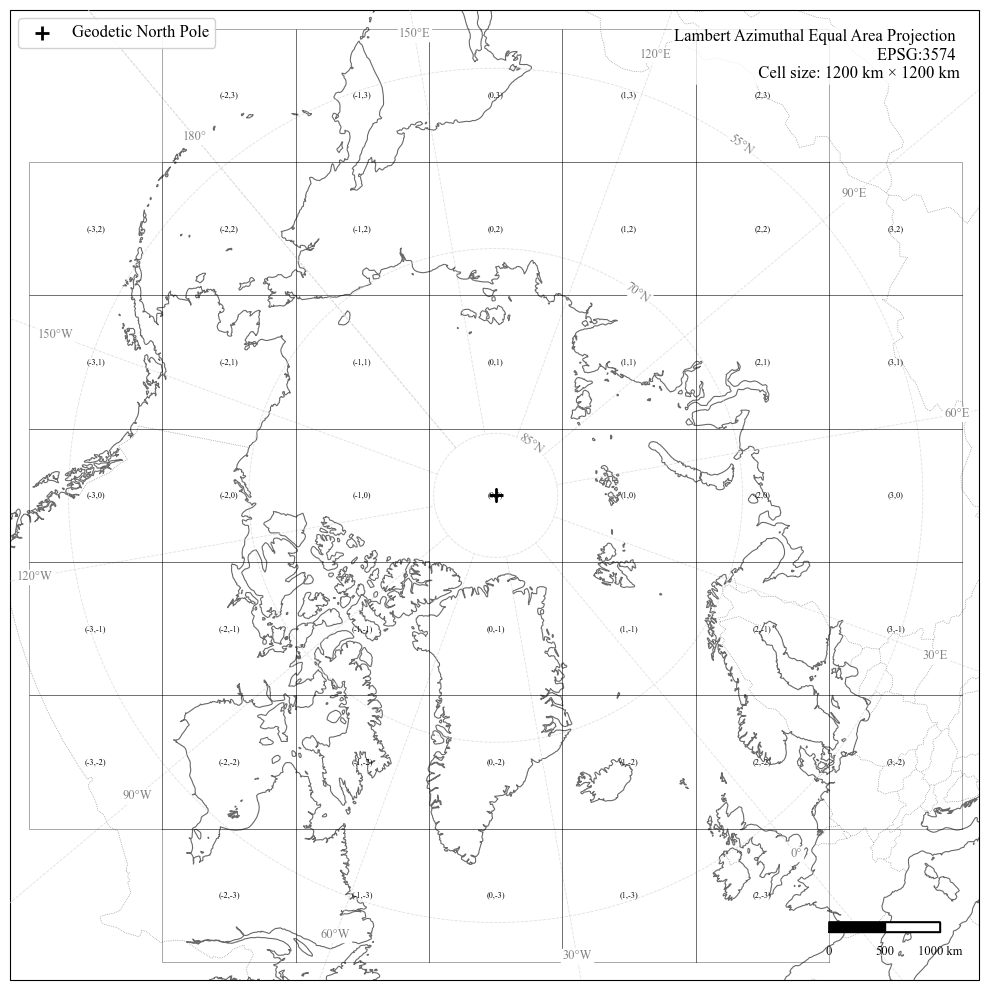

In [41]:
fig, ax, grid_solution1, stations_df = plot_arctic_map_with_laea_grid_solution1(
    csv_path_stations=path_stations_SWADO,
    cell_size=cell_size,
    lat_south=lat_south,
    lat_north=90,
    projection="3574",
    grid_cell_label=True,
    grid_cell_label_fontsize=6
)

## 3. Solution 2: North Pole at the Intersection of Four Cells

In Solution 2, the projected North Pole is located at the corner shared by four central cells. This avoids placing a cell centre directly on the coordinate origin. As a result, each cell centre lies within one quadrant of the projected coordinate system, which makes it possible to define a unique quadrant-based cell ID.

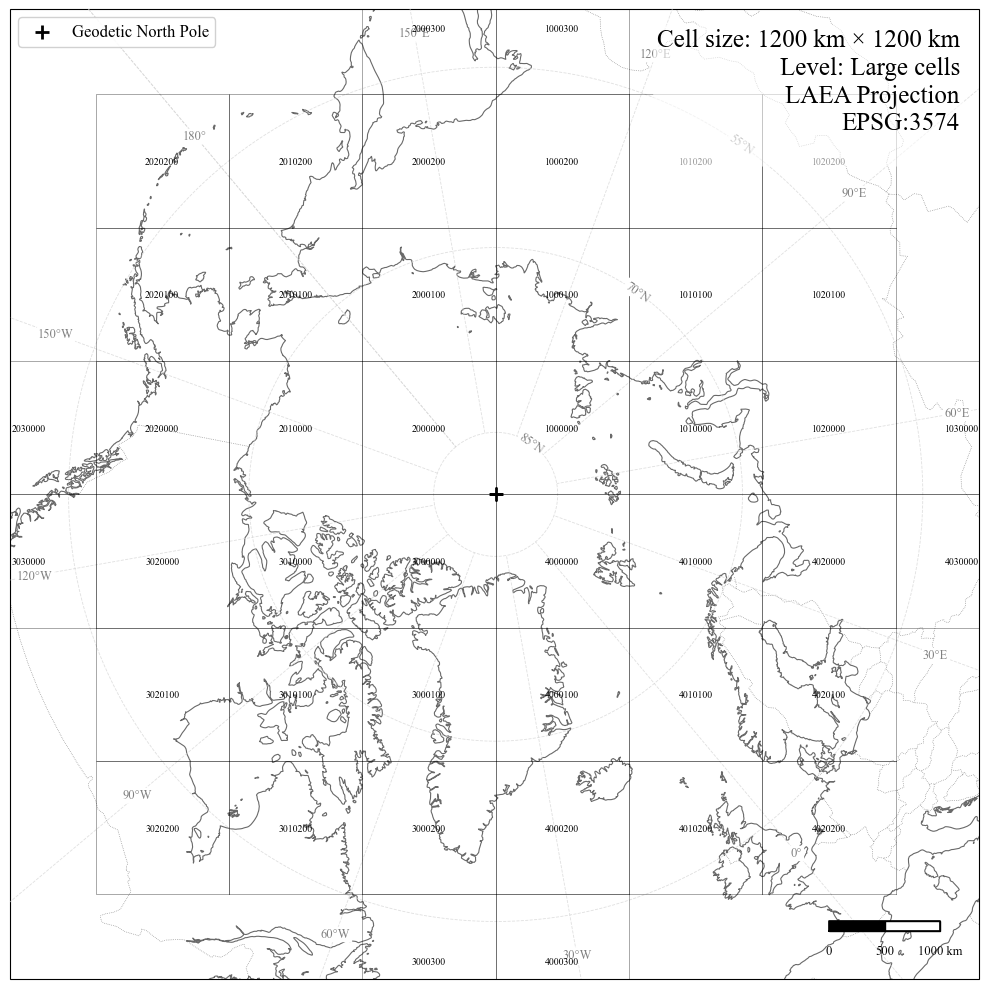

In [42]:
fig, ax, grid_large, stations_df = plot_arctic_map_with_laea_grid_solution2_level(
    csv_path_stations=path_stations_SWADO,
    cell_size=cell_size,
    determine_cell_size="large",
    lat_south=lat_south,
    lat_north=90,
    projection="3574",
    grid_cell_label=True,
    grid_cell_label_fontsize=7
)

## 4. Hierarchical Grid Levels

The selected grid uses three spatial levels: large, medium and small. The side lengths follow a strict 1:2:4 hierarchy. Each large cell is divided into four medium cells, and each medium cell is divided into four small cells. This allows the spatial resolution to be adapted to the density of available IPP observations.

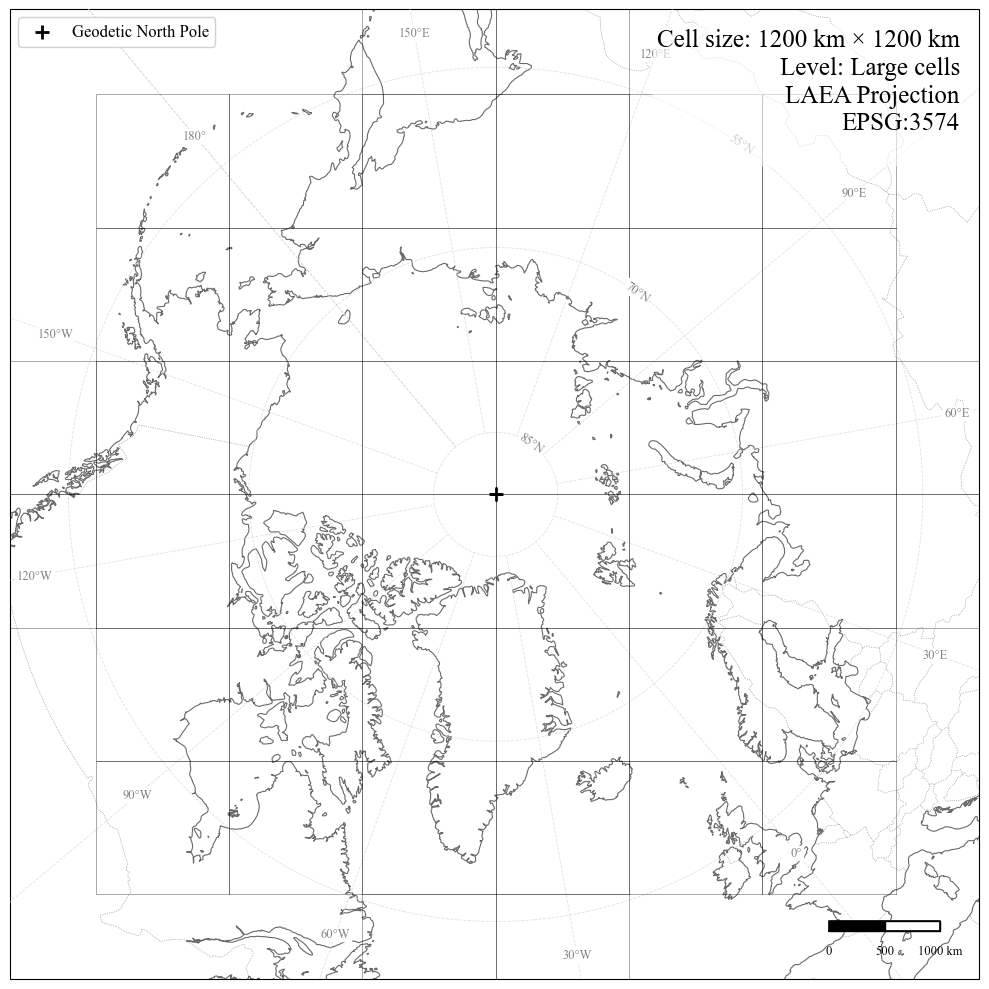

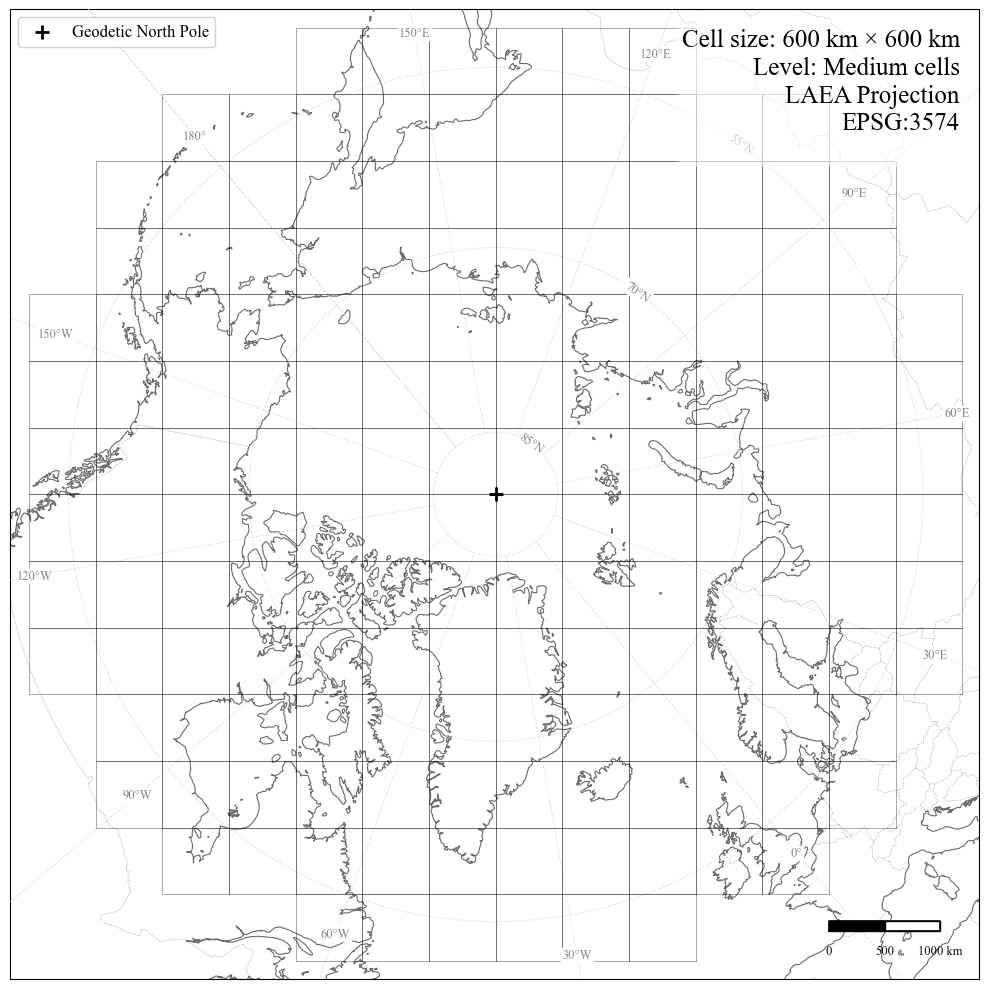

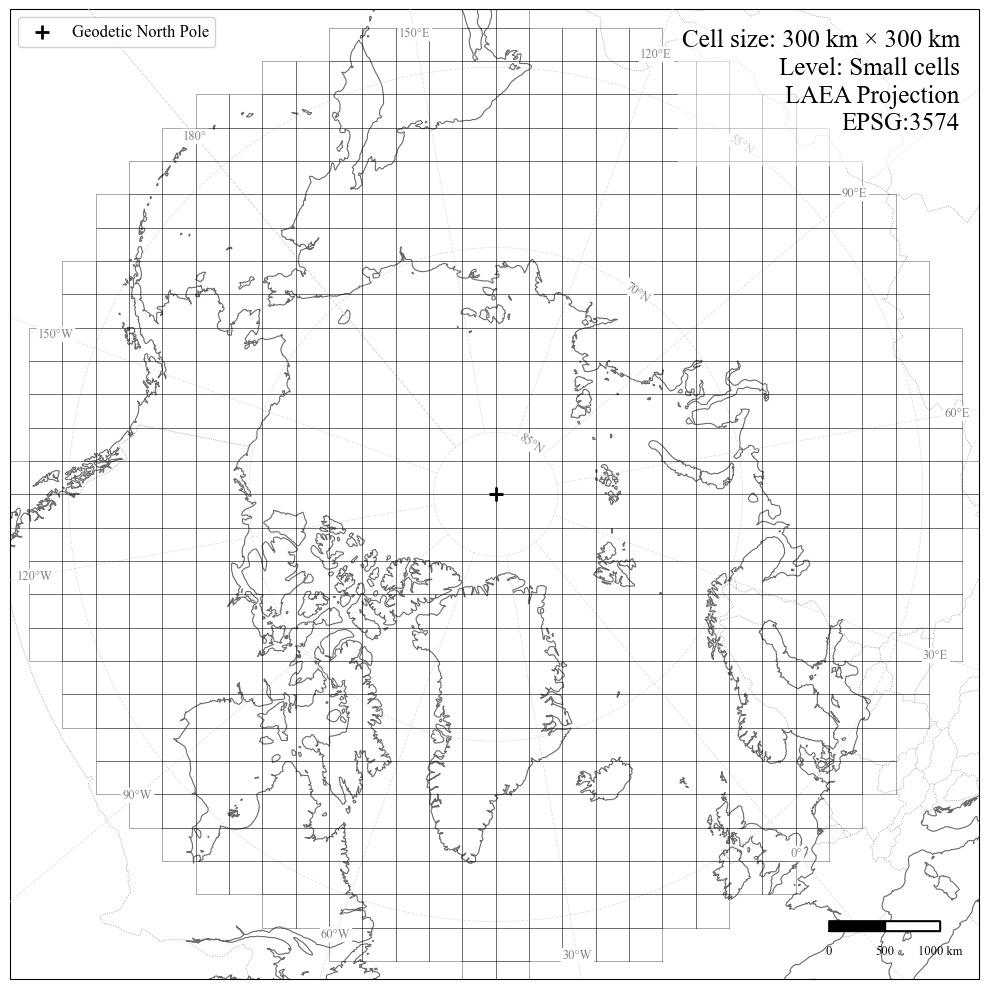

In [43]:
for level in ["large", "medium", "small"]:
    fig, ax, grid_df_plot, stations_df = plot_arctic_map_with_laea_grid_solution2_level(
        csv_path_stations=path_stations_SWADO,
        cell_size=cell_size,
        determine_cell_size=level,
        lat_south=lat_south,
        lat_north=90,
        projection="3574",
        grid_cell_label=False
    )

## 5. Cell ID Naming System

For Solution 2, each cell is assigned a unique ID of the form

\[
Q A A B B C D.
\]

Here, \(Q\) denotes the quadrant of the projected coordinate system. The digit pair \(AA\) gives the large-cell index in the local projected \(x\)-direction, and \(BB\) gives the large-cell index in the local projected \(y\)-direction. The digit \(C\) identifies the medium-cell subdivision within the large cell, while \(D\) identifies the small-cell subdivision within the medium cell.